# Synthetic Benchmark datasets


In [39]:
library(tidyverse)
library(ggplot2)

In [7]:
dt <- read_tsv("../../assembly/qc/qc_full.tsv", show_col_types = FALSE)
head(dt)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,59,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments,1429,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of secondary alignments,102,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of bases in mapped sequences,64585949,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of mapped bases,63548451,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA


Transform some of the values:

A transcript is considered to be single-copy (SC) if it has only one hit; otherwise it is considered multi-copy (MC). We do the same for the assembly and then compute the fraction of missing multi-copy gene as

    MMC = 1 - |{MCinASM} ∩ {MCinREF}| / |{MCinREF}|

In the ideal case of a perfect assembly, %MMC should be zero.

In [ ]:
dt %>% 
    group_by(asm_name) %>%
    mutate(mmc = 1 -  )

ERROR: Error in parse(text = input): <text>:3:0: unexpected end of input
1: dt %>% 
2: 
  ^


In [81]:
|asm.dup_cnt                                               |haplotype1 |asmgene           |1136          |1161         |
|asm.dup_sum                                               |haplotype1 |asmgene           |3885          |3912         |
|asm.frag                                                  |haplotype1 |asmgene           |2             |3            |
|asm.full_dup                                              |haplotype1 |asmgene           |88            |177          |
|asm.full_sgl                                              |haplotype1 |asmgene           |34099         |34009        |
|asm.part10+                                               |haplotype1 |asmgene           |4             |5            |
|asm.part10-                                               |haplotype1 |asmgene           |1904          |1892         |
|asm.part50+                                               |haplotype1 |asmgene           |21            |32           |
|ref.dup_cnt                                               |haplotype1 |asmgene           |1468          |1468         |
|ref.dup_sum                                               |haplotype1 |asmgene           |4509          |4509         |
|ref.frag                                                  |haplotype1 |asmgene           |0             |0            |
|ref.full_dup                                              |haplotype1 |asmgene           |0             |0            |
|ref.full_sgl                                              |haplotype1 |asmgene           |36118         |36118        |
|ref.part10+                                               |haplotype1 |asmgene           |0             |0            |
|ref.part10-                                               |haplotype1 |asmgene           |0             |0            |
|ref.part50+                                               |haplotype1 |asmgene           |0             |0            |

ERROR: Error in parse(text = input): <text>:1:1: unexpected '|'
1: |
    ^


### Compare duplex to herro

In [27]:
dt_herro_vs_duplex <- dt %>%
  filter(str_detect(asm_name, "published")) %>%
  filter(!str_detect(asm_name, "nopolish")) %>%
  filter(asm_method=="phased_verkko") %>%
  mutate(
    seq_type = case_when(
      str_detect(asm_name, "duplex") ~ "duplex",
      str_detect(asm_name, "herro") ~ "herro",
      TRUE ~ NA_character_
    ),
    asm_name = str_remove(asm_name, "duplex|herro") %>%
        str_replace("__", "_") %>%
        str_remove_all("_$")
  ) %>%
  

head(dt_herro_vs_duplex)

metric,value,haplotype,asm_method,asm_name,source,chromosome,seq_type
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,4,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex
Number of primary alignments,752,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex
Number of secondary alignments,64,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex
Number of bases in mapped sequences,60150575,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex
Number of mapped bases,59551592,haplotype1,phased_verkko,published_chr19_15x,stat,NA,duplex


In [32]:
print(dt_herro_vs_duplex %>%
  distinct(metric), n = Inf)

# A tibble: 94 × 1
   metric                                                   
   <chr>                                                    
 1 Number of mapped sequences                               
 2 Number of primary alignments                             
 3 Number of secondary alignments                           
 4 Number of primary alignments with >65535 CIGAR operations
 5 Number of bases in mapped sequences                      
 6 Number of mapped bases                                   
 7 Number of substitutions                                  
 8 Number of insertions in [0,50)                           
 9 Number of insertions in [50,100)                         
10 Number of insertions in [100,300)                        
11 Number of insertions in [300,400)                        
12 Number of insertions in [400,1000)                       
13 Number of insertions in [1000,inf)                       
14 Number of deletions in [0,50)                            
15 Nu

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


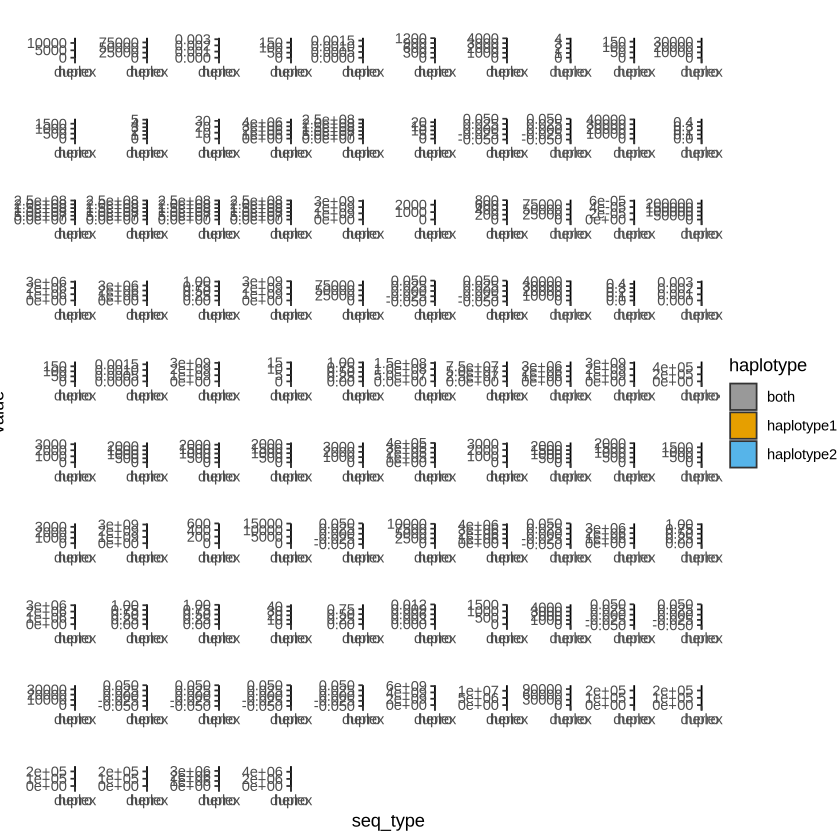

In [64]:
dt_herro_vs_duplex %>% 
    filter(asm_name == "published") %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

In [70]:

dt_herro_vs_duplex_cat_chr <- dt_herro_vs_duplex %>% 
    filter(asm_name == "published") %>%
    group_by(seq_type, metric, haplotype) %>%
    summarise(value = sum(value, na.rm = TRUE), .groups = 'drop')

In [80]:
dt_herro_vs_duplex %>%
  filter(asm_name == "published") %>%
  group_by(seq_type, metric, haplotype, source) %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(
    formatted_value = case_when(
      metric == "NG50" ~ paste0(round(value/1e6, 2), " Mb"),
      metric == "qv" ~ as.character(round(value, 2)),
      metric %in% c("all_switch_rate", "switch_rate") ~ paste0(round(value * 100, 2), "%"),
      TRUE ~ as.character(round(value, 2))
    )
  ) %>%
  select(-value) %>%  # Remove original value column
  pivot_wider(
    names_from = seq_type, 
    values_from = formatted_value
  ) %>%
  arrange(source, haplotype, metric) %>%
  knitr::kable()



|metric                                                    |haplotype  |source            |duplex        |herro        |
|:---------------------------------------------------------|:----------|:-----------------|:-------------|:------------|
|asm.dup_cnt                                               |haplotype1 |asmgene           |1136          |1161         |
|asm.dup_sum                                               |haplotype1 |asmgene           |3885          |3912         |
|asm.frag                                                  |haplotype1 |asmgene           |2             |3            |
|asm.full_dup                                              |haplotype1 |asmgene           |88            |177          |
|asm.full_sgl                                              |haplotype1 |asmgene           |34099         |34009        |
|asm.part10+                                               |haplotype1 |asmgene           |4             |5            |
|asm.part10-                  

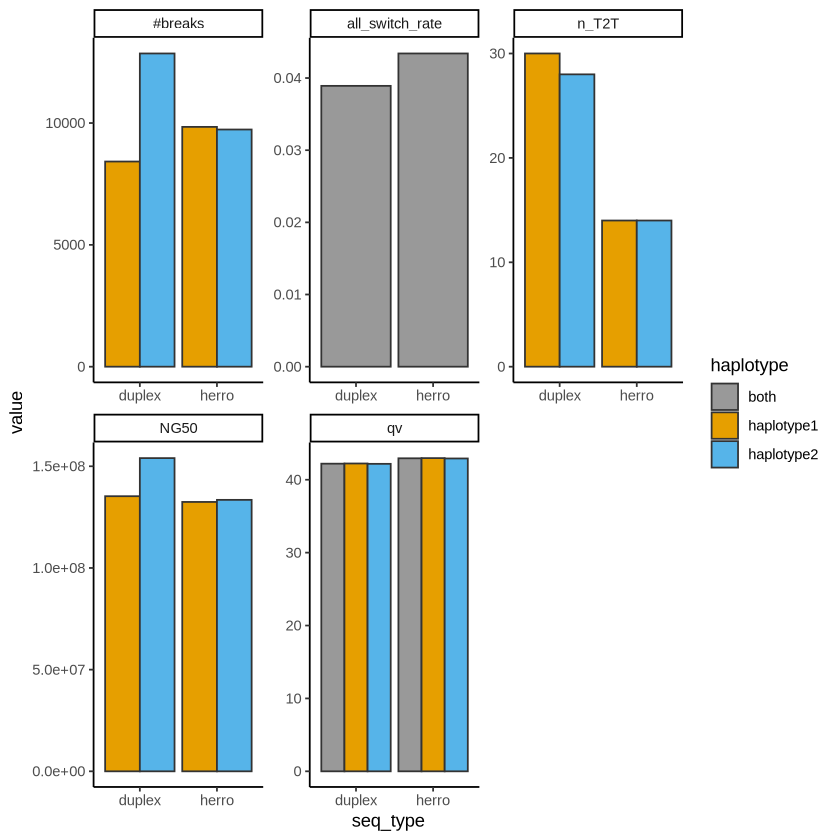

In [67]:
dt_herro_vs_duplex_cat_chr  %>% 
    filter(metric %in% c('NG50', 'n_T2T', 'qv', 'all_switch_rate', '#breaks')) %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()